# Noise Schedule

以下の拡散過程

$$
\begin{align}

q(\bold x_t|\bold x_{t-1}) = \mathcal N(\bold x_t; \sqrt{1 - \beta_t}\bold x_{t-1}, \beta_t I)

\end{align}
$$

における$\beta_t$の設定をノイズスケジュールと呼ぶ。

条件は以下の2点

- $\beta_t \in [0, 1]$
- $\bold x_T$がガウスノイズに収束する

$\beta_t$が単調増加である必要はない。

学習・推論においてはこの$\beta_t$に関連する幾つかの量を使用する。

- $\beta_t$：拡散過程において、前の時刻のデータに加えるノイズの量
- $\alpha_t = 1 - \beta_t$：前の時刻のデータがどれだけ残るか
- $\bar \alpha_t = \prod_i^t \alpha_i$：時刻$t$の時点で、元のデータがどれだけ残るか
- $\tilde\beta_t = \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t}\beta_t$: 真の事後分散

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

T = 1000
t = np.arange(1, T + 1)
t_1 = t - 1

def plot(beta, alpha, bar_alpha, tilde_beta, snr):
    snr = bar_alpha / (1 - bar_alpha)
    plt.plot(t, beta, label=r"$\beta_t$")
    plt.plot(t, alpha, label=r"$\alpha_t$")
    plt.plot(t, bar_alpha, label=r"$\bar \alpha_t$")
    plt.plot(t, tilde_beta, label=r"$\tilde\beta_t$")
    plt.plot(t, snr, label=r"$\operatorname{SNR}_t$")
    plt.xlabel("t")
    plt.ylim(-0.1, 1.1)
    plt.legend();

## Constant

定数

$$
\begin{align}

\beta_t &= \beta \\

\alpha_t &= 1 - \beta \\

\bar \alpha_t
&= \prod_{i=1}^t \alpha_i \\
&= \prod_{i=1}^t (1 - \beta) \\
&= (1 - \beta)^t

\end{align}
$$

$\beta=0.02$の場合

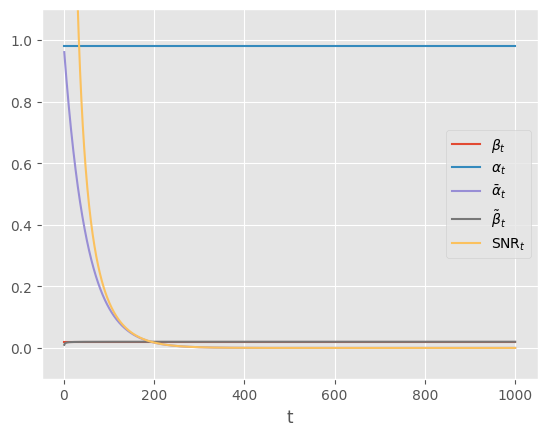

In [2]:
beta = np.array([0.02] * (T + 1))
alpha = 1 - beta
bar_alpha = np.cumprod(alpha)
tilde_beta = (1 - bar_alpha[t_1]) / (1 - bar_alpha[t]) * beta[t]
nsr = bar_alpha / (1 - bar_alpha)
plot(beta[t], alpha[t], bar_alpha[t], tilde_beta, nsr[t])

## Linear

線形

$$
\begin{align}

\beta_t &= \beta_1 + \frac{t}{T}(\beta_T - \beta_1) \\

\alpha_t &= 1 - \beta_t \\

\end{align}
$$

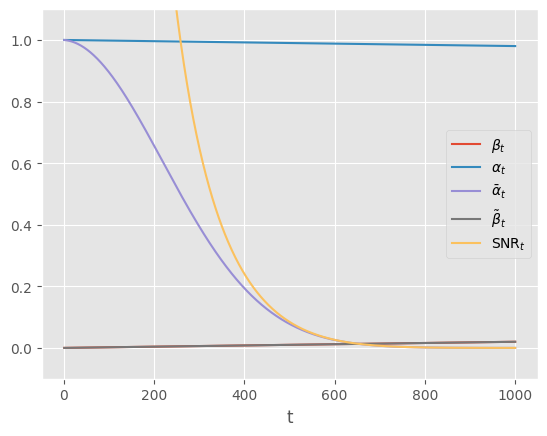

In [3]:
beta_1 = 1e-4
beta_T = 0.02
beta = np.linspace(beta_1, beta_T, T + 1)
alpha = 1 - beta
bar_alpha = np.cumprod(alpha)
tilde_beta = (1 - bar_alpha[t_1]) / (1 - bar_alpha[t]) * beta[t]
nsr = bar_alpha / (1 - bar_alpha)
plot(beta[t], alpha[t], bar_alpha[t], tilde_beta, nsr[t])

## Cosine

Improved Denoising Diffusion Probabilistic Models（2021）で後から提案されたやつ。

$$
\begin{align}

\bar\alpha_t &= \frac { \cos^2 \left( \frac{t / T + s}{1 + s} \cdot \frac{\pi}{2} \right) }{ \cos^2 \left( \frac{s}{1 + s} \cdot \frac{\pi}{2} \right) } \\

\alpha_t &= \frac{\bar\alpha_t}{\bar\alpha_{t - 1}} \\

\beta_t &= 1 - \alpha_t

\end{align}
$$

$s$は小さいオフセット。$\bar\alpha_t$を定義して、$\alpha_t$と$\beta_t$は後から合わせる。

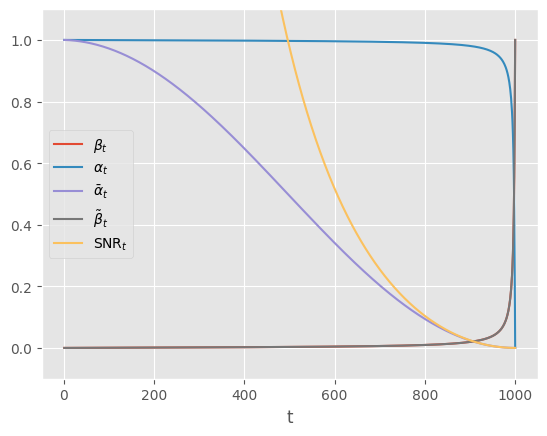

In [4]:
s = 0.008
t_ = np.arange(T + 1)
bar_alpha = (np.cos((t_ / T + s) / (1 + s) * np.pi / 2) ** 2) / (np.cos(s / (1 + s) * np.pi / 2) ** 2)
alpha = bar_alpha[t] / bar_alpha[t_1]
beta = 1 - alpha
tilde_beta = (1 - bar_alpha[t_1]) / (1 - bar_alpha[t]) * beta
bar_alpha = bar_alpha[t]
nsr = bar_alpha / (1 - bar_alpha)
plot(beta, alpha, bar_alpha, tilde_beta, nsr)